# 08 — Unsupervised learning

**Dataset:** `aim_2023`

**Question:** Which stable operating regimes appear without recurrence-derived labels?

## Method

Fit robust window features and K-means on training recordings. Select cluster count by internal structure and seed stability.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_fusion import render_unsupervised_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "aim_2023"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,228.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,217.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,210.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
3,5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3...,25.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
4,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,89.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
5,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,33.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
6,6732a35a8f6343dcf041f1a3ad40d6760331513a2556c4...,21.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
7,7208a43e77536a72e401c00f01a793130fb6688d28fb80...,9.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
8,73093667f33a7f710fc20059989a002071359119e1e9c0...,10.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
9,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,107.95,dynamic_candidate,False,inferred_uniform_from_metadata,train


In [2]:
EXPERIMENT_OPTIONS = {}
EXPERIMENT_OPTIONS

{}

,task,split,metric,value,sample_count,reference_source
0,driving_regime_clustering,train,selected_cluster_count,3.000000,662,internal_selection
1,driving_regime_clustering,train,silhouette,0.666522,662,internal_only
2,driving_regime_clustering,train,seed_adjusted_rand_index,1.000000,662,internal_only
3,driving_regime_clustering,train,mean_centroid_distance,1.938081,662,none
4,driving_regime_clustering,validation,mean_centroid_distance,2.844564,61,none
5,driving_regime_clustering,test,mean_centroid_distance,1.363307,213,none
6,driving_regime_clustering,all,mean_centroid_distance,1.866359,936,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,936,18,9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e72...,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,936,936,window_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,936.0,NaN,NaN,NaN,118.839744,101.772946,0.0,40.0,94.0,168.0,446.0
end_s,936.0,NaN,NaN,NaN,128.839744,101.772946,10.0,50.0,104.0,178.0,456.0
prediction_kind,936,1,driving_regime_cluster,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,936.0,NaN,NaN,NaN,-1.866359,1.524314,-8.53311,-2.818059,-1.010003,-0.706213,-0.308189
label_status,936,1,provisional_unverified,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,936.0,NaN,NaN,NaN,0.581197,0.862672,0.0,0.0,0.0,1.25,2.0
distance_to_centroid,936.0,NaN,NaN,NaN,1.866359,1.524314,0.308189,0.706213,1.010003,2.818059,8.53311


,count,mean,median,std,min,max
recording_id,,,,,,
73093667f33a7f710fc20059989a002071359119e1e9c0a4128b67729755da33,1,-0.589769,-0.589769,NaN,-0.589769,-0.589769
27937681c8199780c6cbce603f217d5a4457c351e84fa3cd7cfc62bfd270c550,105,-1.802916,-0.601051,1.685070,-6.131618,-0.308189
db4d46d3c8abd3b8d2327e52a99599c63e7bd8ed5f1b122d3047d731fc6d2684,6,-0.616504,-0.625121,0.058902,-0.685390,-0.543566
7208a43e77536a72e401c00f01a793130fb6688d28fb8080941e14cc5752b0ca,1,-0.631964,-0.631964,NaN,-0.631964,-0.631964
5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3c778cee8923a932a75,9,-0.651466,-0.653167,0.103102,-0.771214,-0.507435
18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b55502d04ff71359269,110,-1.662239,-0.723472,1.426019,-5.981030,-0.350405
dc8bf44eb4cc0becf1c5ebe252a515c98193744c2031498501de80e036899758,84,-0.888532,-0.748582,0.660009,-4.815262,-0.609755
bace0e92b25324e8afbd0e5f6698b01a921780a2385e02419965fa97e3e796c4,117,-1.764556,-0.882784,1.400789,-7.236458,-0.590665
c3c503093a73b359d513d025d9185c7ada423099650828cbd4fdba12d1d7aafc,6,-0.932611,-0.932018,0.066637,-1.014677,-0.847043


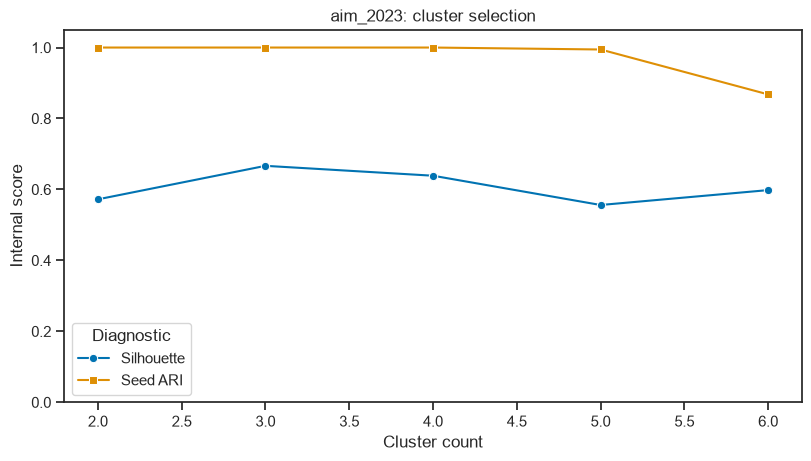

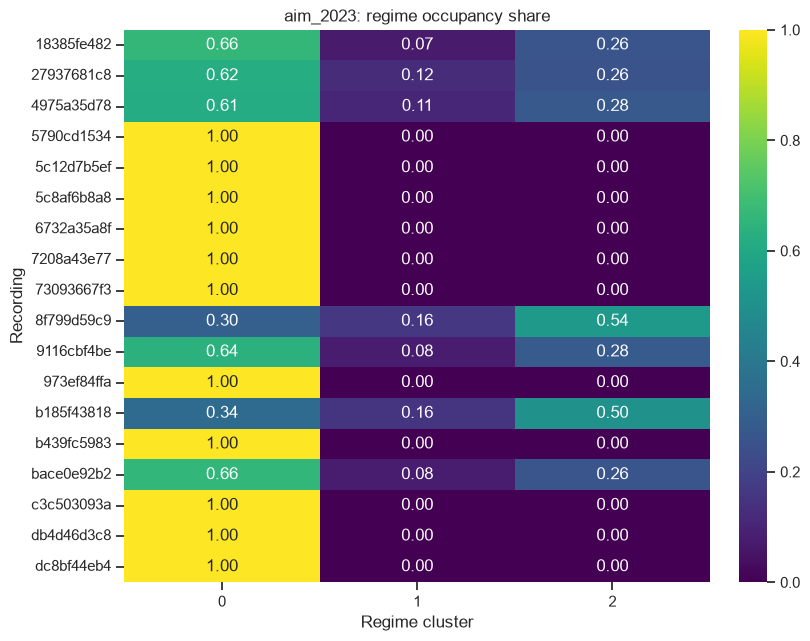

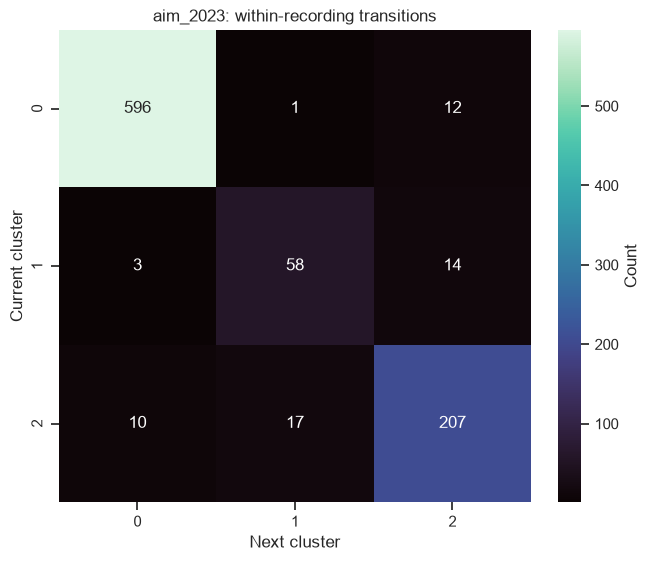

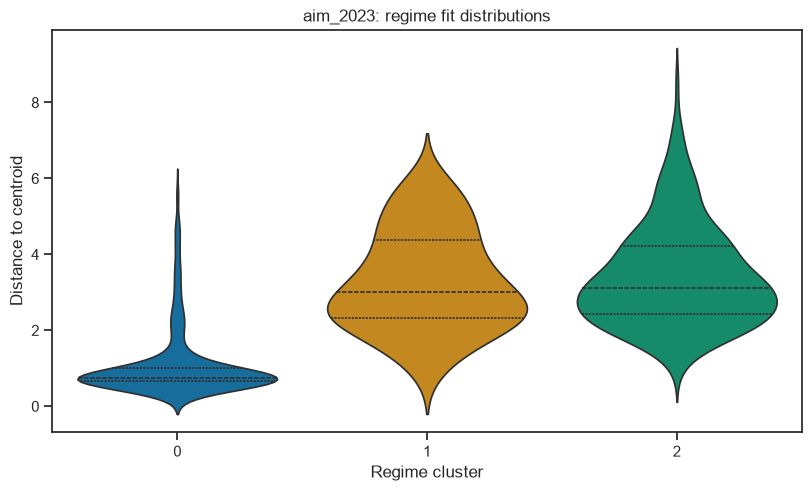

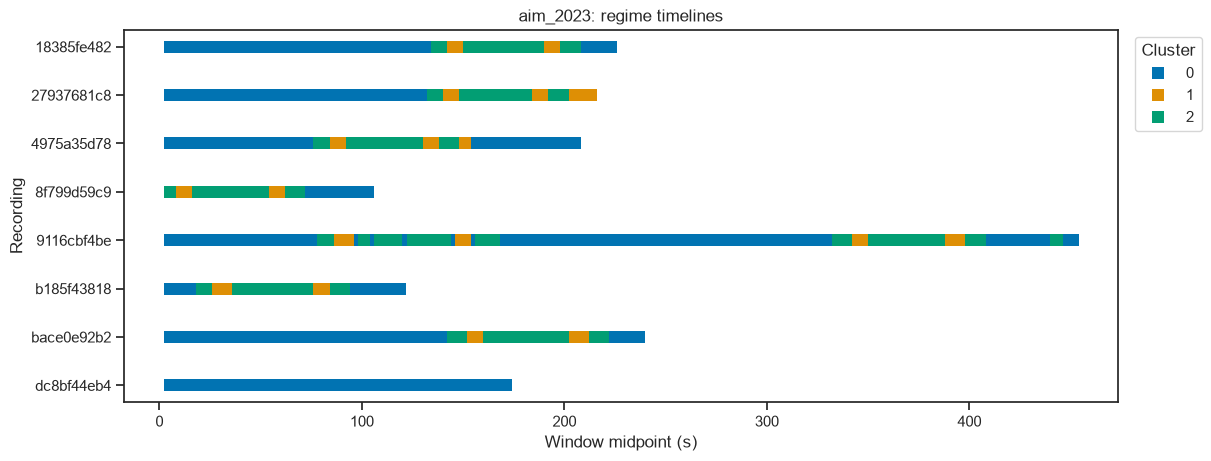

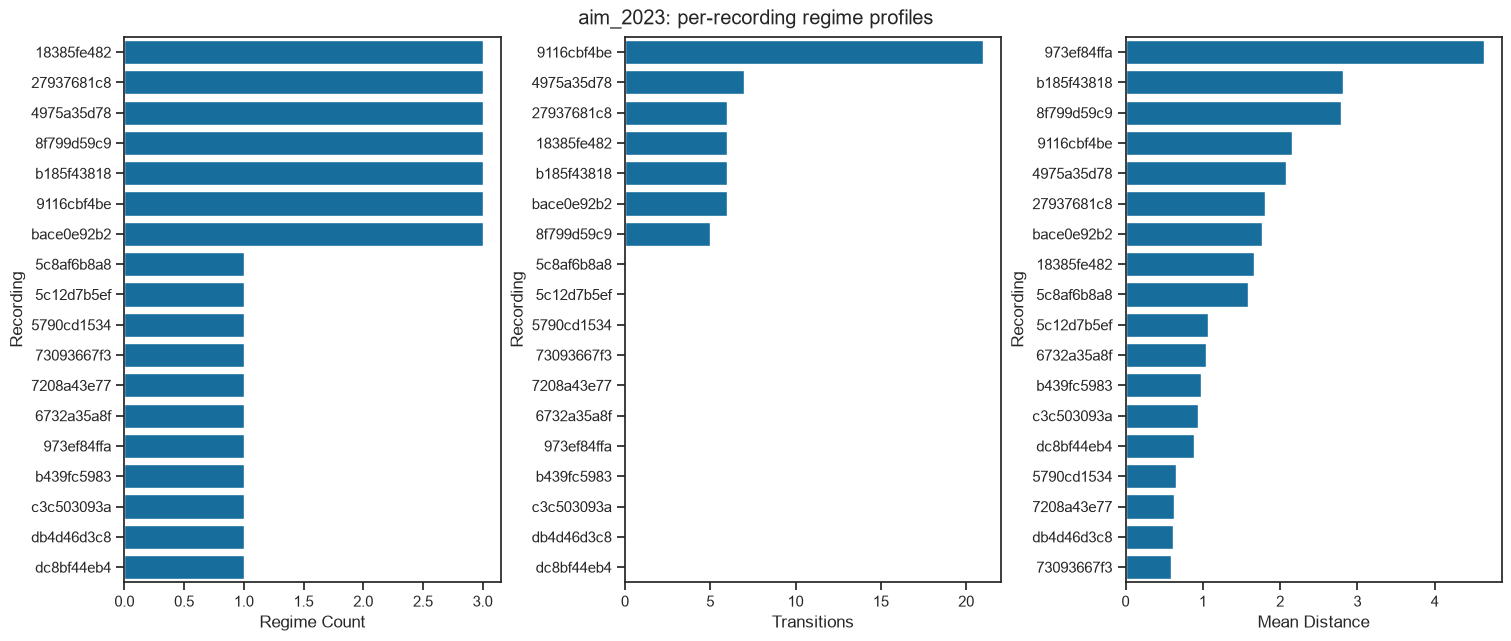

In [3]:
METHOD = "08_unsupervised_learning"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_unsupervised_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,3.719
clock_provenance,inferred_uniform_from_metadata
sample_rate_hz,20.0
channels,"[InlineAcc, LateralAcc, RollRate, PitchRate, Y..."
label_provenance,cluster_regime_not_lap


## Reading

Stable clusters describe regimes until independent lap labels exist.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.